SETUP

In [3]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1", ) #Load using Pandas
df.head() # Display the first few rows of the dataset

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


DATA CLEANING (Very Important)

In [6]:
# Remove missing values
df = df.dropna()

In [7]:
# Remove returned orders (InvoiceNo starting with "C")
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [8]:
# Create a "Revenue" column
df['Revenue'] = df['Quantity'] * df['UnitPrice']


In [15]:
# Final dataset info
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
 8   Revenue      397924 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 30.4+ MB


,Quantity,UnitPrice,CustomerID,Revenue
count,397924.000000,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171,22.394749
std,180.420210,22.096788,1713.169877,309.055588
min,1.000000,0.000000,12346.000000,0.000000
25%,2.000000,1.250000,13969.000000,4.680000
50%,6.000000,1.950000,15159.000000,11.800000
75%,12.000000,3.750000,16795.000000,19.800000
max,80995.000000,8142.750000,18287.000000,168469.600000


BASIC ANALYSIS

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')

In [10]:
df['Revenue'].sum() #Total revenue

8911407.904

In [11]:
df['CustomerID'].nunique() #Number of unique customers


4339

In [12]:
df['InvoiceNo'].nunique() #Number of unique orders

18536

TOP PERFORMING PRODUCTS

In [13]:
# Most sold products (by quantity)
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products_qty


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [26]:
# Highest revenue products
top_products_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

CATEGORY / COUNTRY ANALYSIS

In [14]:
# Revenue by country
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_revenue


Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [15]:
# Orders by country
orders_country = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
orders_country


Country
United Kingdom    16649
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          95
Spain                90
Australia            57
Portugal             57
Switzerland          51
Name: InvoiceNo, dtype: int64

VISUALIZATIONS

In [25]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')

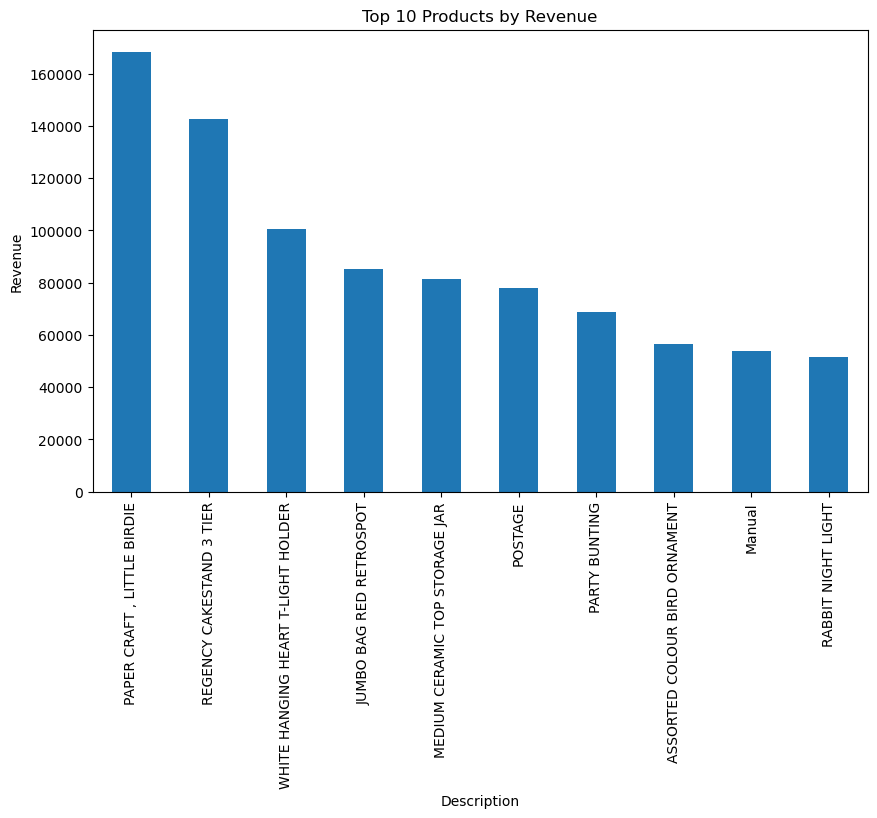

In [ ]:
# top 10 products by revenue
plt.figure(figsize=(10,6))
top_products_revenue.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()


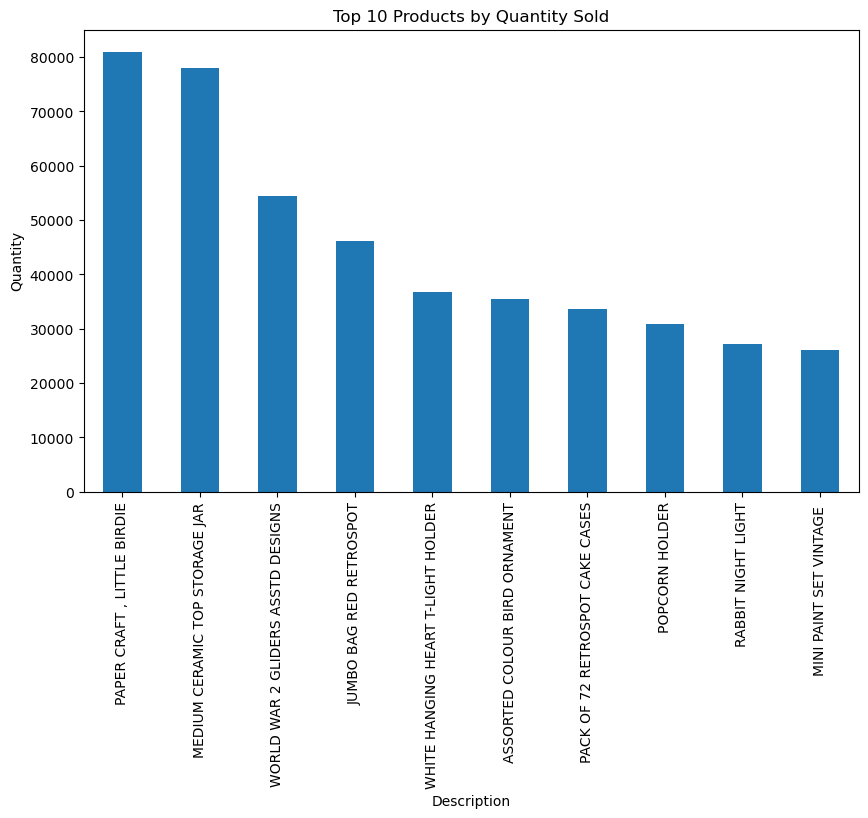

In [23]:
# Top 10 products by quantity sold
plt.figure(figsize=(10,6))
top_products_qty.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.ylabel("Quantity")
plt.show()


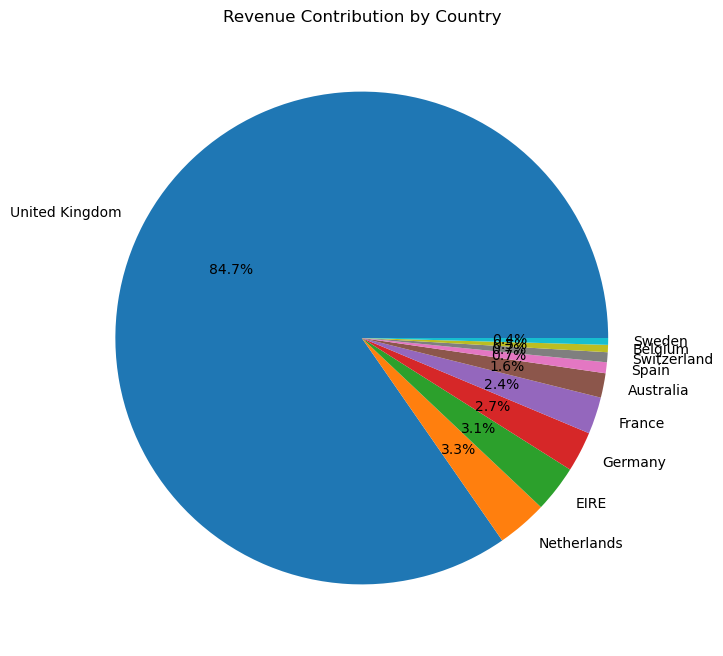

In [17]:
# Pie chart — Revenue by Country
plt.figure(figsize=(8,8))
country_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Contribution by Country")
plt.ylabel("")
plt.show()


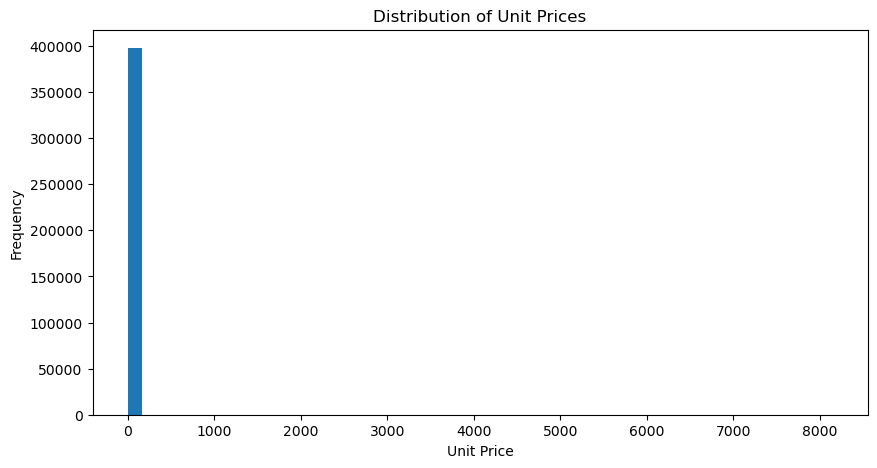

In [18]:
# Histogram — Unit Price
plt.figure(figsize=(10,5))
plt.hist(df["UnitPrice"], bins=50)
plt.title("Distribution of Unit Prices")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()


Insights:

- The UK contributes the highest revenue among all countries.

- Certain products such as “WHITE HANGING HEART T-LIGHT HOLDER” are top sellers.

- Product revenue distribution is highly skewed—few products generate majority of sales.

- Quantity sold does not always equal revenue (some items have low price).

- Seasonal spikes may be visible in certain months